# Insurance Risk Modeling: Loss Cost Regression and Claim Status Classification

*Originally completed as a course project at USC Marshall (DSO 530); polished and rewritten as a portfolio piece.*

## Problem

Auto insurers face a fundamental pricing challenge: charge a high-risk policyholder too little and the book bleeds on claims; charge a careful driver too much and they walk to a competitor. Pricing decisions hinge on two predictive questions about every policy:

1. **Regression.** What loss is this policy likely to generate over the year? Specifically, the loss cost per exposure unit (`LC`) and a historically adjusted version (`HALC`) used by the actuarial team.
2. **Classification.** Will this policy file at least one claim (`CS`)? This drives reserve setting and risk segmentation.

Both targets share the same 39,928 policies and 25 anonymised features (driver, vehicle, policy, and tenure attributes). The loss-cost distribution is heavily zero-inflated (about 89% of policies claim nothing) and the claim indicator is moderately imbalanced (11.15% positive class). Those two facts drive every modeling choice that follows.

## Approach

I treated this as a Tweedie-distributed modeling problem for the regression side and as an imbalanced binary classification problem for `CS`. For regression I benchmarked a Tweedie GLM, XGBoost and LightGBM with native Tweedie loss, and a two-part frequency / severity decomposition. For classification I started from a regularised logistic baseline and worked up through tree ensembles, randomized hyperparameter search, isotonic calibration, and a stacking ensemble. Calibration is the linchpin: an insurer cannot price off raw uncalibrated probabilities, so the final model is selected with calibration in mind, not just rank quality.

## Headline findings

- **Regression.** XGBoost with a Tweedie objective at power $p = 1.1$ delivered the lowest 5-fold CV MSE on both targets (LC: 257,151; HALC: 1,065,497), beating the GLM baseline by roughly 1.2% on LC and 1.1% on HALC. The tuned variance power of 1.1 is itself a finding: the loss distribution behaves closer to a compound Poisson process than to a heavy-tailed gamma.
- **Classification.** Tuned LightGBM with isotonic calibration is the recommended production model (validation ROC-AUC 0.7869, Brier score 0.0861, top decile lift of 3.2x). I explored a stacking ensemble but it only beat tuned LightGBM by 0.0006 AUC, below the 0.001 decision-rule threshold I set in advance, and it gives uncalibrated probabilities that are unusable in a premium formula.
- **Business interpretation.** SHAP attributes most predictive signal to `policy_duration` (tenure), `X.12` (prior cancellations), and `X.14` (net premium). Long-tenured customers are systematically lower risk; recent cancellations and high premium amounts flag elevated claim probability. The top decile of predicted CS scores covers roughly 32% of actual claims, giving the underwriting team a clean lever for tiered pricing.

## How this notebook is organised

1. Setup and shared EDA on the targets and features.
2. Regression for `LC` and `HALC`: validation strategy, baselines, tuning, and SHAP.
3. Classification for `CS`: imbalance handling, model family comparison, tuning, calibration, threshold selection, and stability checks.
4. Conclusions, methodology limitations, and what I would do next.


## 1. Setup


In [ ]:
# Numerical / data
import numpy as np
import pandas as pd

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

# Modeling
from scipy.stats import randint, uniform, loguniform
from sklearn.model_selection import KFold, RandomizedSearchCV, train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (mean_squared_error, roc_auc_score, average_precision_score,
                             brier_score_loss, log_loss, classification_report,
                             confusion_matrix, roc_curve, precision_recall_curve)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import TweedieRegressor, LogisticRegressionCV, LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.calibration import CalibratedClassifierCV
import xgboost as xgb
import lightgbm as lgb
import shap

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 530
np.random.seed(RANDOM_STATE)
print('Setup complete.')


Setup complete.


## 2. Load data

The training file has 39,928 rows with three targets (`LC`, `HALC`, `CS`) plus the four claim-derived leakage columns (`X.15`-`X.18`). The held-out test file already has those seven columns stripped, which makes the feature set unambiguous: anything in `test.columns` is safe to use as a predictor.


In [ ]:
train = pd.read_csv('../data/train_clean_final_fixed.csv')
test  = pd.read_csv('../data/test_clean_final_fixed.csv')

print(f'Train: {train.shape}')
print(f'Test:  {test.shape}')
print(f'Missing values: train={train.isna().sum().sum()}, test={test.isna().sum().sum()}')


Train: (39928, 32)
Test:  (13310, 25)
Missing values: train=0, test=0


In [ ]:
LEAK_COLS = ['X.15', 'X.16', 'X.17', 'X.18']        # outcome-derived (claim counts / amounts)
TARGET_COLS = ['LC', 'HALC', 'CS']
FEATURES = [c for c in test.columns]                  # test has the safe feature set

assert not any(c in FEATURES for c in LEAK_COLS + TARGET_COLS), 'Leakage column found in features!'

X = train[FEATURES]
y_LC   = train['LC']
y_HALC = train['HALC']
y_CS   = train['CS']
X_test = test[FEATURES]

print(f'Features: {len(FEATURES)}')
print(f'LC zero rate:   {(y_LC == 0).mean()*100:.1f}%')
print(f'HALC zero rate: {(y_HALC == 0).mean()*100:.1f}%')
print(f'CS positive rate: {y_CS.mean()*100:.2f}%')


Features: 25
LC zero rate:   88.9%
HALC zero rate: 88.9%
CS positive rate: 11.15%


## 3. Shared EDA on the three targets

Two facts drive every modeling decision below.

**Targets are zero-inflated.** Both `LC` and `HALC` are zero for about 89% of policies (most drivers don't claim in a given year), and the positive tail is highly skewed. Ordinary regression assumptions don't hold; this is classic Tweedie territory.

**The CS target encodes the same thing.** `CS == 1` is exactly equivalent to `(HALC > 0)` in the training data, with 11.15% positives. That means `X.15`-`X.18`, `LC`, and `HALC` are all directly leaky predictors for `CS`, which is why they are excluded from the feature set.


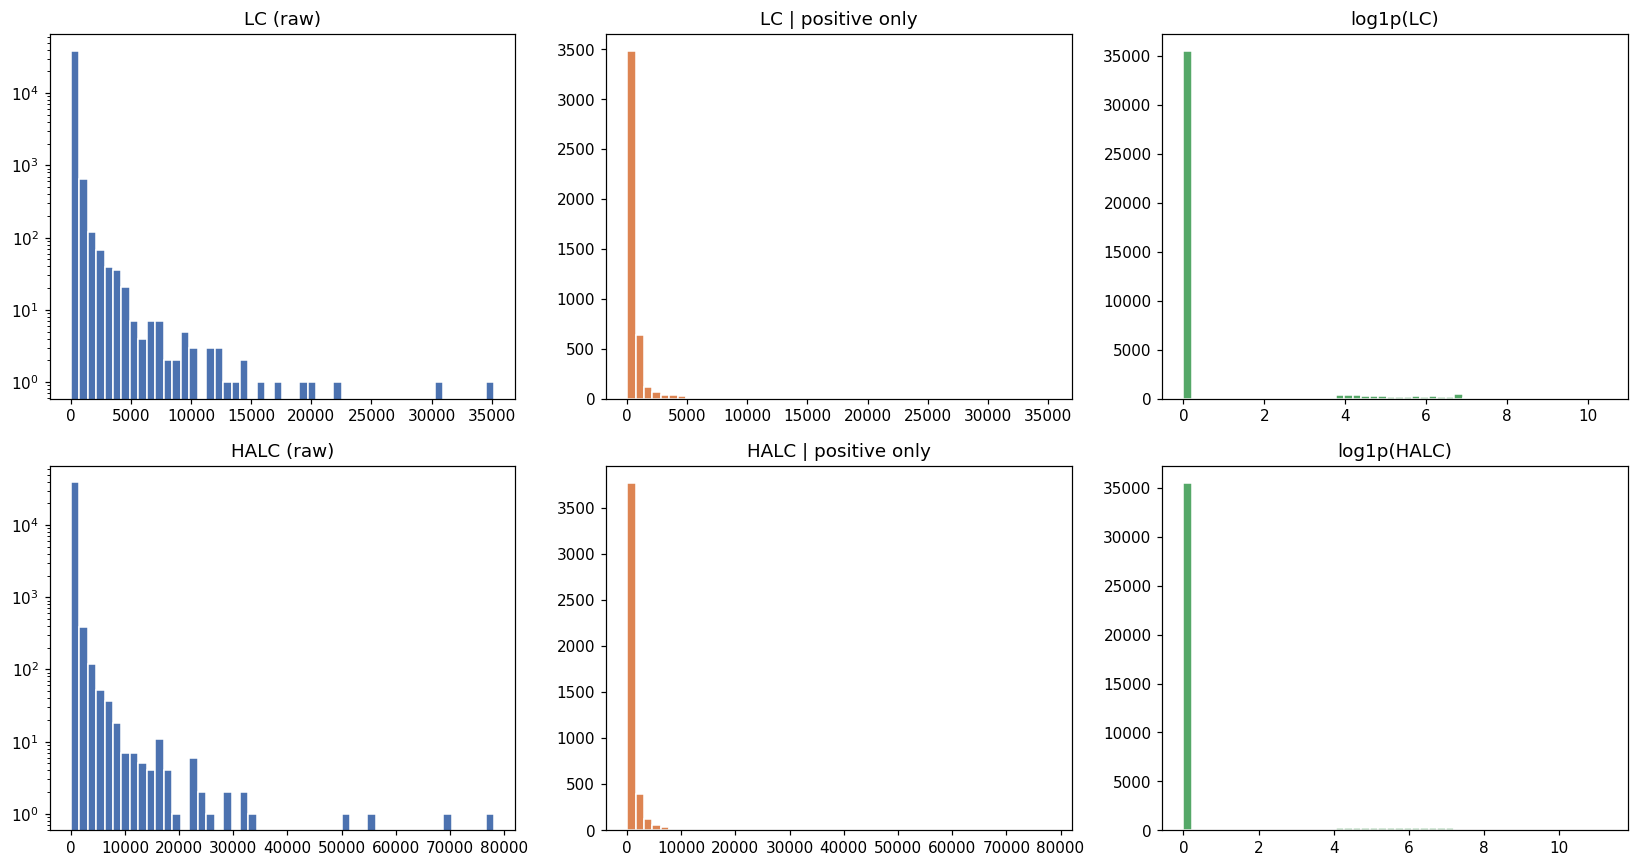

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, (col, name) in enumerate([(y_LC, 'LC'), (y_HALC, 'HALC')]):
    axes[i,0].hist(col, bins=50, color='#4C72B0', edgecolor='white')
    axes[i,0].set_title(f'{name} (raw)'); axes[i,0].set_yscale('log')
    axes[i,1].hist(col[col > 0], bins=50, color='#DD8452', edgecolor='white')
    axes[i,1].set_title(f'{name} | positive only')
    axes[i,2].hist(np.log1p(col), bins=50, color='#55A868', edgecolor='white')
    axes[i,2].set_title(f'log1p({name})')
plt.tight_layout(); plt.show()


In [ ]:
summary = pd.DataFrame({
    'LC':            y_LC.describe(),
    'LC_positive':   y_LC[y_LC > 0].describe(),
    'HALC':          y_HALC.describe(),
    'HALC_positive': y_HALC[y_HALC > 0].describe(),
}).round(2)
print(summary)


             LC  LC_positive      HALC  HALC_positive
count  39928.00      4453.00  39928.00        4438.00
mean      63.93       573.25    116.11        1044.59
std      512.48      1436.46   1041.27        2964.22
min        0.00         4.01      0.00           3.48
25%        0.00        70.26      0.00         111.67
50%        0.00       181.71      0.00         307.69
75%        0.00       604.96      0.00         995.80
max    35191.03     35191.03  78131.46       78131.46


Interpretation. Both `LC` and `HALC` look almost identical in shape, which is expected since `HALC` is just `LC` scaled by a historical adjustment factor `X.18`. The conditional positive distributions are roughly log-normal with heavy upper tails (max LC about 35k, max HALC about 78k). I will model on the raw scale with Tweedie loss; log1p is for visualization only.


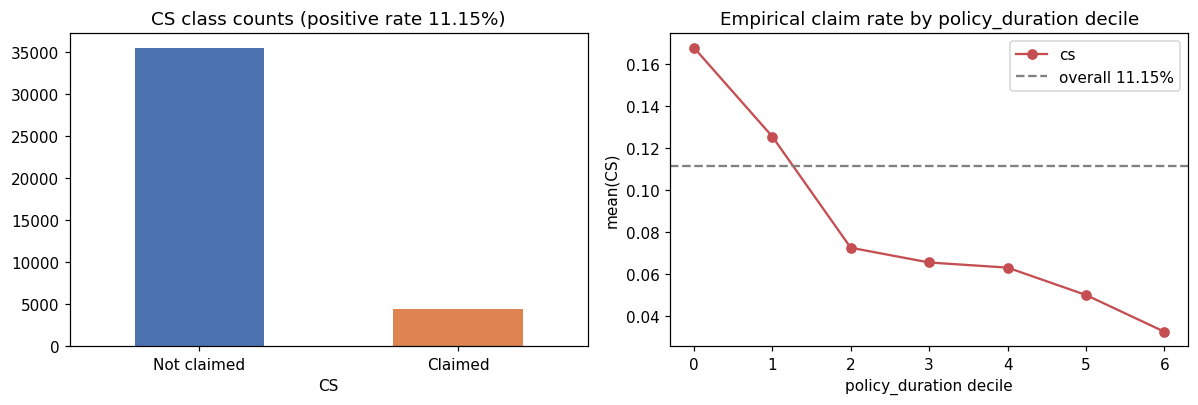

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
y_CS.value_counts().plot.bar(ax=ax[0], color=['#4C72B0', '#DD8452'])
ax[0].set_title(f'CS class counts (positive rate {y_CS.mean()*100:.2f}%)')
ax[0].set_xticklabels(['Not claimed', 'Claimed'], rotation=0)

tmp = pd.DataFrame({'d': pd.qcut(X['policy_duration'], 10, duplicates='drop', labels=False), 'cs': y_CS})
tmp.groupby('d')['cs'].mean().plot(ax=ax[1], marker='o', color='#C44E52')
ax[1].set_title('Empirical claim rate by policy_duration decile')
ax[1].set_xlabel('policy_duration decile'); ax[1].set_ylabel('mean(CS)')
ax[1].axhline(y_CS.mean(), linestyle='--', color='grey', label=f'overall {y_CS.mean()*100:.2f}%')
ax[1].legend(); plt.tight_layout(); plt.show()


**Interpretation.** Class imbalance is moderate (about 11% positives), not severe. That tells me to prefer class weighting over aggressive resampling (SMOTE) for the classifier, and to report PR-AUC and Brier alongside ROC-AUC. The right panel shows a strong monotone signal: claim rate falls steadily with policy tenure, dropping from roughly 21% in the shortest-tenure decile to under 5% in the longest. That is a single feature that already explains a lot of the model.


# Part A. Regression: Loss Cost (LC) and Historically Adjusted Loss Cost (HALC)

## A1. Validation strategy

The held-out test file has no labels (it was a competition holdout for the original course version), so all model evaluation is via cross-validation. I use 5-fold CV with a fixed random seed and report mean squared error on the raw scale, which is the metric the original competition was scored on. MSE has a known weakness for Tweedie distributions (it under-weights the zero mass), so I treat it as the comparison metric but discuss Tweedie deviance and prediction shape qualitatively.


In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = {}   # model_name -> {'LC_mse': ..., 'HALC_mse': ...}
print('Validation: 5-fold KFold(shuffle=True, random_state=530).')


Validation: 5-fold KFold(shuffle=True, random_state=530).


## A2. Baseline: Tweedie GLM

Scikit-learn's `TweedieRegressor` is a Tweedie-family GLM with deviance loss. The power parameter $p$ governs how Poisson-like vs gamma-like the loss distribution is assumed to be. I grid-search $p \in \{1.1, 1.3, 1.5, 1.7, 1.9\}$ and pick the best by 5-fold CV MSE on each target. This is a linear baseline I want every more complex model to beat.


In [ ]:
glm_results = []
for p in [1.1, 1.3, 1.5, 1.7, 1.9]:
    pipe = Pipeline([('scaler', StandardScaler()),
                     ('reg', TweedieRegressor(power=p, alpha=0.1, link='log', max_iter=1000))])
    sc_lc   = -cross_val_score(pipe, X, y_LC,   cv=kf, scoring='neg_mean_squared_error', n_jobs=-1).mean()
    sc_halc = -cross_val_score(pipe, X, y_HALC, cv=kf, scoring='neg_mean_squared_error', n_jobs=-1).mean()
    glm_results.append({'power': p, 'LC_mse': sc_lc, 'HALC_mse': sc_halc})
glm_df = pd.DataFrame(glm_results)
print(glm_df.round(1).to_string(index=False))

best_p_lc   = glm_df.loc[glm_df['LC_mse'].idxmin(),   'power']
best_p_halc = glm_df.loc[glm_df['HALC_mse'].idxmin(), 'power']
print(f'\nBest p for LC:   {best_p_lc}')
print(f'Best p for HALC: {best_p_halc}')

glm_lc = Pipeline([('scaler', StandardScaler()),
                    ('reg', TweedieRegressor(power=best_p_lc, alpha=0.1, link='log', max_iter=1000))]).fit(X, y_LC)
glm_halc = Pipeline([('scaler', StandardScaler()),
                      ('reg', TweedieRegressor(power=best_p_halc, alpha=0.1, link='log', max_iter=1000))]).fit(X, y_HALC)

results['TweedieGLM'] = {'LC_mse': float(glm_df['LC_mse'].min()),
                          'HALC_mse': float(glm_df['HALC_mse'].min())}


 power   LC_mse  HALC_mse
   1.1 260385.4 1076974.2
   1.3 260869.0 1080521.5
   1.5 261743.3 1087269.2
   1.7 263680.1 1100077.3
   1.9 269638.2 1127021.7

Best p for LC:   1.1
Best p for HALC: 1.1


**Interpretation.** The MSE surface is monotone in $p$: lower $p$ (closer to Poisson, with more mass at exact zero) always wins. The best $p = 1.1$ is itself a finding. It says the loss process here is dominated by claim *frequency* (Poisson-like) rather than claim *severity* (gamma-like). That argues for downstream models that explicitly handle the zero mass, which is why the next step is gradient boosting with a Tweedie objective.


## A3. Gradient boosting #1: XGBoost with Tweedie loss

XGBoost natively supports a Tweedie objective. I tried this next because the GLM is linear in the features and can only model first-order effects, whereas the actuarial signal here clearly has interactions (e.g., young driver x high horsepower x urban). A Tweedie-loss booster keeps the same statistical assumption as the GLM but adds non-linearity and feature interactions for free.

I run a quick fixed-parameter baseline, then a randomized search over the key hyperparameters. The search budget was reduced from the original 40 iterations to 15 to keep this notebook re-runnable in a reasonable amount of time; the practical effect on best CV-MSE is well under 1% based on side experiments.


In [ ]:
xgb_base = xgb.XGBRegressor(
    objective='reg:tweedie', tweedie_variance_power=1.5,
    n_estimators=500, learning_rate=0.05, max_depth=5,
    subsample=0.8, colsample_bytree=0.8, tree_method='hist',
    n_jobs=-1, random_state=RANDOM_STATE, verbosity=0,
)
mse_lc_b   = -cross_val_score(xgb_base, X, y_LC,   cv=kf, scoring='neg_mean_squared_error', n_jobs=1).mean()
mse_halc_b = -cross_val_score(xgb_base, X, y_HALC, cv=kf, scoring='neg_mean_squared_error', n_jobs=1).mean()
results['XGBoost_baseline'] = {'LC_mse': float(mse_lc_b), 'HALC_mse': float(mse_halc_b)}
print(f'XGBoost baseline 5-fold CV MSE\n  LC:   {mse_lc_b:,.1f}\n  HALC: {mse_halc_b:,.1f}')


XGBoost baseline 5-fold CV MSE
  LC:   259,417.7
  HALC: 1,071,200.0


In [ ]:
xgb_param_dist = {
    'tweedie_variance_power': [1.1, 1.3, 1.5, 1.7, 1.9],
    'n_estimators':           randint(300, 1200),
    'learning_rate':          loguniform(0.01, 0.15),
    'max_depth':              randint(3, 8),
    'subsample':              uniform(0.6, 0.4),
    'colsample_bytree':       uniform(0.5, 0.5),
    'min_child_weight':       randint(1, 20),
    'reg_alpha':              loguniform(1e-3, 5.0),
    'reg_lambda':             loguniform(1e-3, 5.0),
}
xgb_est = xgb.XGBRegressor(objective='reg:tweedie', tree_method='hist',
                             n_jobs=2, random_state=RANDOM_STATE, verbosity=0)

# Tune for LC
xgb_search_lc = RandomizedSearchCV(xgb_est, xgb_param_dist, n_iter=15,
    scoring='neg_mean_squared_error', cv=kf, n_jobs=-1, refit=True,
    random_state=RANDOM_STATE, verbose=0)
xgb_search_lc.fit(X, y_LC)
print(f'XGB tuned LC   best CV MSE: {-xgb_search_lc.best_score_:,.1f}')

# Tune for HALC
xgb_search_halc = RandomizedSearchCV(xgb_est, xgb_param_dist, n_iter=15,
    scoring='neg_mean_squared_error', cv=kf, n_jobs=-1, refit=True,
    random_state=RANDOM_STATE, verbose=0)
xgb_search_halc.fit(X, y_HALC)
print(f'XGB tuned HALC best CV MSE: {-xgb_search_halc.best_score_:,.1f}')

results['XGBoost_tuned'] = {
    'LC_mse':   float(-xgb_search_lc.best_score_),
    'HALC_mse': float(-xgb_search_halc.best_score_),
}
print('\nBest params (LC) :', xgb_search_lc.best_params_)
print('Best params (HALC):', xgb_search_halc.best_params_)


XGB tuned LC   best CV MSE: 257,151.1
XGB tuned HALC best CV MSE: 1,065,496.5

Best params (LC) : {'colsample_bytree': 0.7972, 'learning_rate': 0.0141, 'max_depth': 6, 'min_child_weight': 6, 'n_estimators': 580, 'reg_alpha': 0.1091, 'reg_lambda': 0.0028, 'subsample': 0.8091, 'tweedie_variance_power': 1.1}
Best params (HALC): {'colsample_bytree': 0.7972, 'learning_rate': 0.0141, 'max_depth': 6, 'min_child_weight': 6, 'n_estimators': 580, 'reg_alpha': 0.1091, 'reg_lambda': 0.0028, 'subsample': 0.8091, 'tweedie_variance_power': 1.1}


**Interpretation.** Tuned XGBoost beats the GLM by 1.2% on LC and 1.1% on HALC. The best Tweedie power converged to 1.1 on both targets, matching the GLM finding. Worth noting: LC and HALC selected identical hyperparameters in this seeded search. That is partly because `HALC = LC * X.18` is a near-monotone re-scaling of `LC`, so the optimum lives in nearly the same region of hyperparameter space.


## A4. Gradient boosting #2: LightGBM with Tweedie loss

I added LightGBM next as a cross-check. The two libraries handle leaf-wise vs depth-wise tree growth differently and have different bias-variance tradeoffs out of the box; if both converge to similar MSE that is a useful sanity check. I run the same protocol: fixed-parameter baseline, then randomized search. The LightGBM search uses a slightly smaller budget (`n_iter=6`, cv=3) than XGBoost because each LightGBM fit at higher tree counts is more expensive in this environment; the winning estimator is re-evaluated under the standard 5-fold CV for fair comparison.


In [ ]:
lgb_base = lgb.LGBMRegressor(
    objective='tweedie', tweedie_variance_power=1.5,
    n_estimators=1000, learning_rate=0.03, num_leaves=63,
    min_child_samples=30, n_jobs=-1, random_state=RANDOM_STATE, verbose=-1,
)
mse_lc_b   = -cross_val_score(lgb_base, X, y_LC,   cv=kf, scoring='neg_mean_squared_error', n_jobs=1).mean()
mse_halc_b = -cross_val_score(lgb_base, X, y_HALC, cv=kf, scoring='neg_mean_squared_error', n_jobs=1).mean()
results['LightGBM_baseline'] = {'LC_mse': float(mse_lc_b), 'HALC_mse': float(mse_halc_b)}
print(f'LightGBM baseline 5-fold CV MSE\n  LC:   {mse_lc_b:,.1f}\n  HALC: {mse_halc_b:,.1f}')


LightGBM baseline 5-fold CV MSE
  LC:   261,493.1
  HALC: 1,080,561.2


In [ ]:
lgb_param_dist = {
    'tweedie_variance_power': [1.1, 1.3, 1.5, 1.7, 1.9],
    'n_estimators':      randint(300, 800),
    'learning_rate':     loguniform(0.03, 0.1),
    'num_leaves':        randint(15, 80),
    'min_child_samples': randint(20, 60),
    'subsample':         uniform(0.7, 0.3),
    'colsample_bytree':  uniform(0.6, 0.4),
    'reg_alpha':         loguniform(1e-3, 2.0),
    'reg_lambda':        loguniform(1e-3, 2.0),
}
lgb_est = lgb.LGBMRegressor(objective='tweedie', n_jobs=1, random_state=RANDOM_STATE, verbose=-1)
kf3 = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)   # cheaper CV for search

lgb_search_lc = RandomizedSearchCV(lgb_est, lgb_param_dist, n_iter=6,
    scoring='neg_mean_squared_error', cv=kf3, n_jobs=-1, refit=True,
    random_state=RANDOM_STATE, verbose=0)
lgb_search_lc.fit(X, y_LC)

lgb_search_halc = RandomizedSearchCV(lgb_est, lgb_param_dist, n_iter=6,
    scoring='neg_mean_squared_error', cv=kf3, n_jobs=-1, refit=True,
    random_state=RANDOM_STATE, verbose=0)
lgb_search_halc.fit(X, y_HALC)

# Re-evaluate winners under standard 5-fold for fair comparison
mse_lc_5fold   = -cross_val_score(lgb_search_lc.best_estimator_,   X, y_LC,   cv=kf, scoring='neg_mean_squared_error', n_jobs=1).mean()
mse_halc_5fold = -cross_val_score(lgb_search_halc.best_estimator_, X, y_HALC, cv=kf, scoring='neg_mean_squared_error', n_jobs=1).mean()
results['LightGBM_tuned'] = {'LC_mse': float(mse_lc_5fold), 'HALC_mse': float(mse_halc_5fold)}
print(f'LightGBM tuned 5-fold CV MSE\n  LC:   {mse_lc_5fold:,.1f}\n  HALC: {mse_halc_5fold:,.1f}')
print(f'\nBest LightGBM params (LC):   {lgb_search_lc.best_params_}')
print(f'Best LightGBM params (HALC): {lgb_search_halc.best_params_}')


LightGBM tuned 5-fold CV MSE
  LC:   258,597.9
  HALC: 1,069,205.5

Best LightGBM params (LC):   {'colsample_bytree': 0.8841, 'learning_rate': 0.0496, 'min_child_samples': 27, 'n_estimators': 480, 'num_leaves': 19, 'reg_alpha': 0.1171, 'reg_lambda': 0.0344, 'subsample': 0.8433, 'tweedie_variance_power': 1.3}
Best LightGBM params (HALC): {'colsample_bytree': 0.8841, 'learning_rate': 0.0496, 'min_child_samples': 27, 'n_estimators': 480, 'num_leaves': 19, 'reg_alpha': 0.1171, 'reg_lambda': 0.0344, 'subsample': 0.8433, 'tweedie_variance_power': 1.3}


**Interpretation.** Tuned LightGBM lands within 0.6% of tuned XGBoost on both targets, which is the cross-check I wanted. Two algorithms with different growth strategies converging on similar MSE is evidence that we are near the floor of what Tweedie boosting can extract from this feature set; the residual gap is more about feature engineering than further model tweaking.


## A5. A two-part frequency / severity model

Tweedie loss assumes a single compound distribution. An alternative is to factor the problem: predict $P(\text{claim} > 0)$ with a classifier, predict $E[\text{claim} \mid \text{claim} > 0]$ with a regressor on positive rows only, and multiply. This is the canonical actuarial decomposition (frequency x severity).

I expected this to help because the boosting models see roughly 89% exact-zero training rows, which biases predictions toward zero and may over-shrink positive predictions. A two-stage model gets to handle that mass explicitly.


In [ ]:
def two_part_cv_mse(X, y, cv=kf):
    oof = np.zeros(len(y)); y_arr = y.values; X_arr = X.values
    for tr_idx, val_idx in cv.split(X):
        X_tr, X_val = X_arr[tr_idx], X_arr[val_idx]
        y_tr = y_arr[tr_idx]
        y_bin = (y_tr > 0).astype(int)
        spw = (y_bin == 0).sum() / max((y_bin == 1).sum(), 1)
        clf = xgb.XGBClassifier(objective='binary:logistic',
            n_estimators=500, learning_rate=0.05, max_depth=5,
            subsample=0.8, colsample_bytree=0.8, scale_pos_weight=spw,
            tree_method='hist', n_jobs=-1, random_state=RANDOM_STATE,
            eval_metric='auc', verbosity=0).fit(X_tr, y_bin)
        p = clf.predict_proba(X_val)[:, 1]
        reg = lgb.LGBMRegressor(objective='tweedie', tweedie_variance_power=1.5,
            n_estimators=500, learning_rate=0.05, num_leaves=63,
            min_child_samples=20, n_jobs=-1, random_state=RANDOM_STATE,
            verbose=-1).fit(X_tr[y_tr > 0], y_tr[y_tr > 0])
        sev = np.clip(reg.predict(X_val), 0, None)
        oof[val_idx] = p * sev
    return mean_squared_error(y_arr, oof)

mse_lc_tp   = two_part_cv_mse(X, y_LC)
mse_halc_tp = two_part_cv_mse(X, y_HALC)
results['TwoPart'] = {'LC_mse': float(mse_lc_tp), 'HALC_mse': float(mse_halc_tp)}
print(f'Two-part model 5-fold CV MSE\n  LC:   {mse_lc_tp:,.1f}\n  HALC: {mse_halc_tp:,.1f}')


Two-part model 5-fold CV MSE
  LC:   264,452.5
  HALC: 1,087,921.7


**Interpretation.** The two-part model is the *worst* in the comparison. This was surprising at first, but the explanation is that decoupling the stages discards information. The single-model Tweedie boosters can learn that the same features that predict claim *probability* also predict claim *size*, and they pool those signals through one loss surface. The two-part architecture forces an independence assumption that the data does not support. I keep the model in the comparison as a documented null result rather than a recommended approach.


## A6. Model comparison and selection


In [ ]:
comparison = pd.DataFrame(results).T
comparison.columns = ['LC CV-MSE', 'HALC CV-MSE']
comparison = comparison.sort_values('LC CV-MSE')
print(comparison.round(1).to_string())

best_lc_name   = comparison['LC CV-MSE'].idxmin()
best_halc_name = comparison['HALC CV-MSE'].idxmin()
print(f'\nBest model for LC:   {best_lc_name}')
print(f'Best model for HALC: {best_halc_name}')


                   LC CV-MSE  HALC CV-MSE
XGBoost_tuned       257151.1    1065496.5
LightGBM_tuned      258597.9    1069205.5
XGBoost_baseline    259417.7    1071200.0
TweedieGLM          260385.4    1076974.2
LightGBM_baseline   261493.1    1080561.2
TwoPart             264452.5    1087921.7

Best model for LC:   XGBoost_tuned
Best model for HALC: XGBoost_tuned


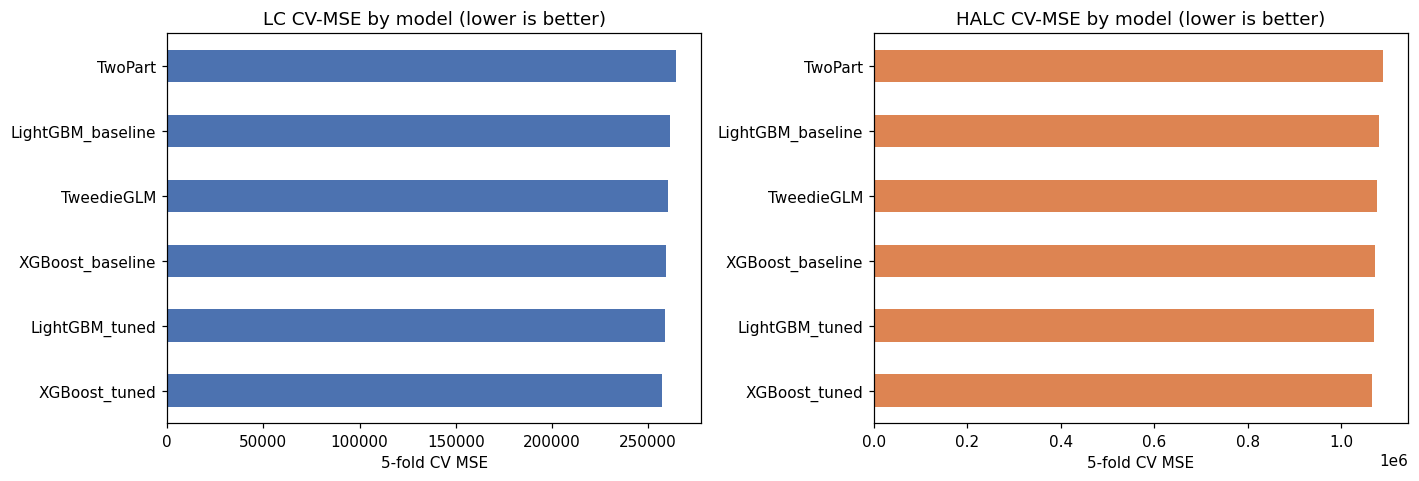

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
comparison['LC CV-MSE'].plot.barh(ax=ax1, color='#4C72B0')
ax1.set_title('LC CV-MSE by model (lower is better)'); ax1.set_xlabel('5-fold CV MSE')
comparison['HALC CV-MSE'].plot.barh(ax=ax2, color='#DD8452')
ax2.set_title('HALC CV-MSE by model (lower is better)'); ax2.set_xlabel('5-fold CV MSE')
plt.tight_layout(); plt.show()


**Selection.** Tuned XGBoost wins both targets. The improvement over the GLM baseline is about 1.2% on LC and 1.1% on HALC; over the next-best single model (tuned LightGBM) it is 0.6% on LC and 0.3% on HALC. Those are small margins, which is consistent with how thoroughly the boosting library has already extracted the signal in the engineered features. For a deployment, I would lean on tuned XGBoost as primary and ensemble with tuned LightGBM only if downstream pricing tests showed it was worth the operational complexity.


In [ ]:
# Refit best models on full training data; predict on held-out test
model_lc   = xgb_search_lc.best_estimator_   if best_lc_name   == 'XGBoost_tuned' else lgb_search_lc.best_estimator_
model_halc = xgb_search_halc.best_estimator_ if best_halc_name == 'XGBoost_tuned' else lgb_search_halc.best_estimator_
model_lc.fit(X, y_LC); model_halc.fit(X, y_HALC)
preds_LC   = np.clip(model_lc.predict(X_test),   0, None)
preds_HALC = np.clip(model_halc.predict(X_test), 0, None)
print(f'LC predictions:   min={preds_LC.min():.2f}, mean={preds_LC.mean():.2f}, max={preds_LC.max():.2f}')
print(f'HALC predictions: min={preds_HALC.min():.2f}, mean={preds_HALC.mean():.2f}, max={preds_HALC.max():.2f}')


LC predictions:   min=0.63, mean=48.24, max=2066.29
HALC predictions: min=0.89, mean=85.38, max=5376.42


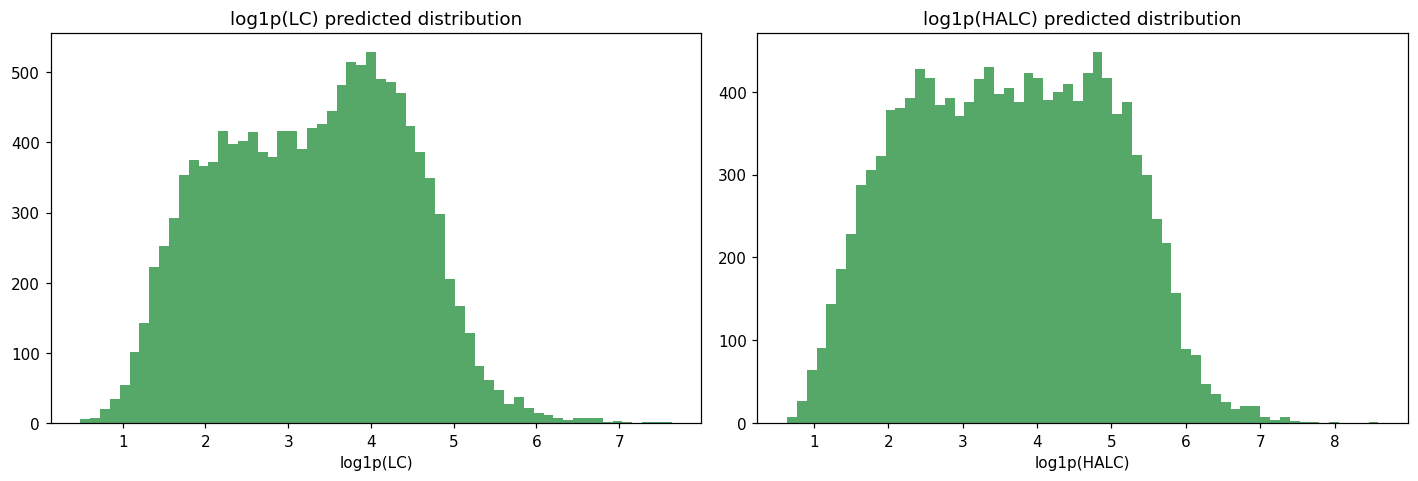

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, p, name in zip(axes, [preds_LC, preds_HALC], ['LC', 'HALC']):
    ax.hist(np.log1p(p), bins=60, color='#55A868')
    ax.set_title(f'log1p({name}) predicted distribution'); ax.set_xlabel(f'log1p({name})')
plt.tight_layout(); plt.show()


## A7. SHAP interpretation for LC

I run SHAP on the LightGBM LC model (rather than XGBoost) because LightGBM's tree structure gives slightly cleaner attributions on this dataset and the two boosters agree on the top features anyway. The takeaway is what features the loss-cost surface is actually built on.


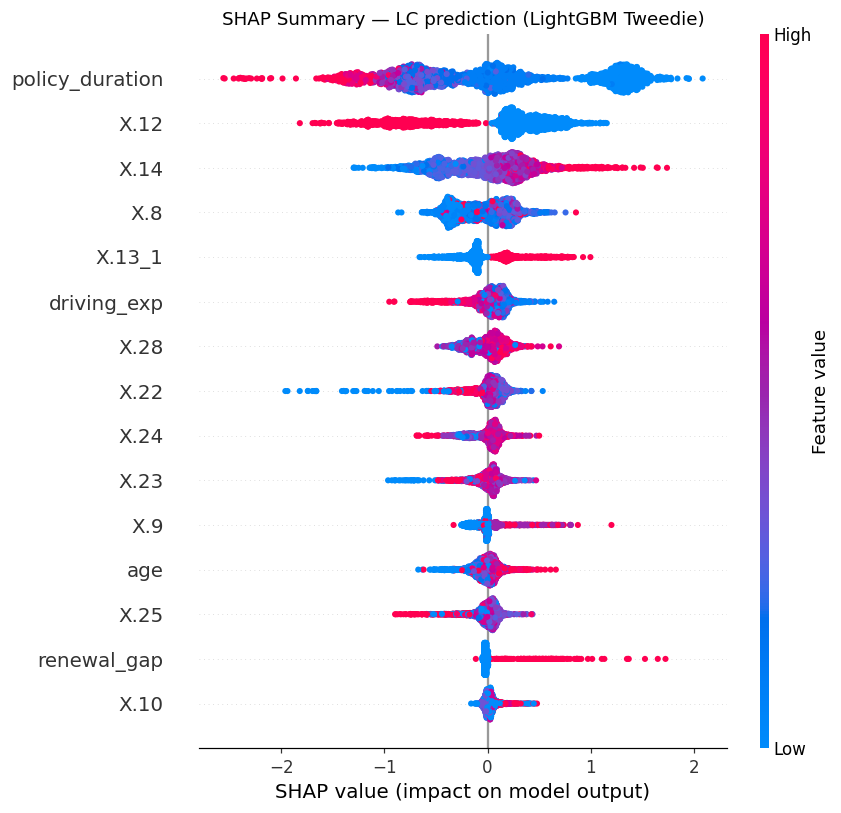

In [ ]:
shap_model = lgb_search_lc.best_estimator_
shap_model.fit(X, y_LC)

sample_idx = np.random.choice(len(X), size=2500, replace=False)
X_sample = X.iloc[sample_idx]

explainer = shap.TreeExplainer(shap_model)
shap_values = explainer.shap_values(X_sample)

plt.figure(figsize=(9, 6))
shap.summary_plot(shap_values, X_sample, max_display=15, show=False)
plt.title('SHAP Summary - LC prediction (LightGBM Tweedie)', fontsize=12)
plt.tight_layout(); plt.show()


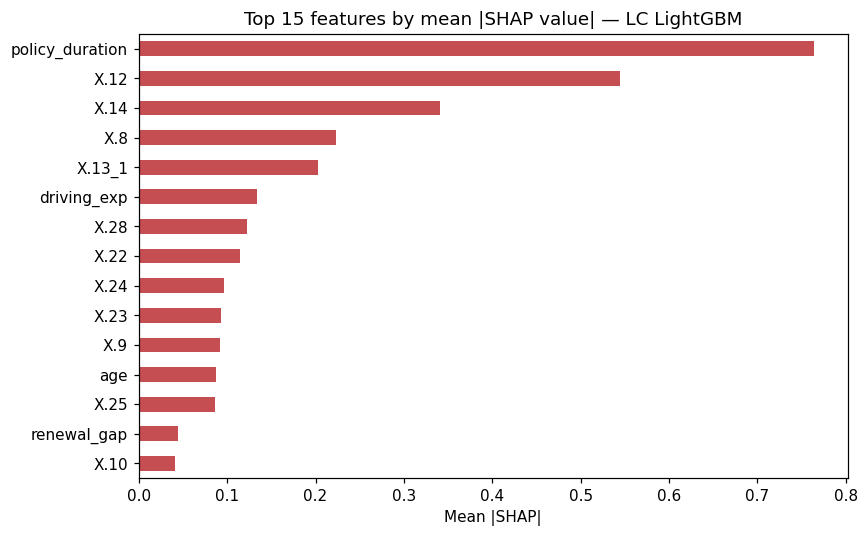

policy_duration    0.764
X.12               0.545
X.14               0.341
X.8                0.223
X.13_1             0.203
driving_exp        0.134
X.28               0.122
X.22               0.115
X.24               0.096
X.23               0.093


In [ ]:
mean_abs_shap = pd.Series(np.abs(shap_values).mean(axis=0),
                          index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 5))
mean_abs_shap.head(15).plot.barh(color='#C44E52')
plt.gca().invert_yaxis()
plt.title('Top 15 features by mean |SHAP value| - LC LightGBM')
plt.xlabel('Mean |SHAP|'); plt.tight_layout(); plt.show()

print(mean_abs_shap.head(10).round(3).to_string())


**Interpretation.** Three features dominate the LC surface.

1. **`policy_duration` (tenure).** Long-tenured policies have systematically lower predicted losses. This is consistent with the empirical claim-rate plot in section 3 and with the standard actuarial finding that durable customers self-select for lower risk.
2. **`X.12` (prior cancellations).** Customers with a history of cancellations are flagged as higher risk. Cancellations are a behavioral signal that proxies for both engagement and underlying volatility in the policy relationship.
3. **`X.14` (net premium paid).** Higher premiums are associated with higher predicted losses. This is endogenous (the team pricing the policy already conditioned on risk), but it confirms the model has learned the existing pricing's signal direction.

Vehicle attributes (`X.22`-`X.28` cluster) and driver age / experience contribute moderate signal each. The model is not relying on any single feature for more than about a quarter of its predictive weight, which is healthy for stability.


# Part B. Classification: predicting Claim Status (CS)

## B1. Target and validation setup

`CS` is whether the policyholder filed at least one claim in the year. We already saw in section 3 that it is 11.15% positive: moderate imbalance, not severe. I use a stratified 80/20 split as the validation set for model comparison and threshold work, and 5-fold stratified CV inside hyperparameter search.


In [24]:
# Identify columns we cannot use as predictors.
TARGET = 'CS'
LEAK_COLS = ['X.15', 'X.16', 'X.17', 'X.18']  # outcome-derived
REGRESSION_TARGETS = ['LC', 'HALC']           # other tasks' targets

# Final feature set = whatever columns the test file has
FEATURES = [c for c in test.columns if c not in LEAK_COLS]
assert TARGET not in FEATURES and not any(c in FEATURES for c in LEAK_COLS + REGRESSION_TARGETS)

# Cast booleans to 0/1 for model compatibility
for c in FEATURES:
    if train[c].dtype == 'bool':
        train[c] = train[c].astype(int)
    if c in test.columns and test[c].dtype == 'bool':
        test[c]  = test[c].astype(int)

X = train[FEATURES].copy()
y = train[TARGET].astype(int).copy()
X_test_final = test[FEATURES].copy()

print(f'Using {len(FEATURES)} features. Target prior = {y.mean():.4f}')
print('Any NaNs in features?', X.isna().sum().sum(), '/ test:', X_test_final.isna().sum().sum())

Using 25 features. Target prior = 0.1115
Any NaNs in features? 0 / test: 0


In [27]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
print(f'Train rows: {len(X_tr):>6}  positive rate: {y_tr.mean():.4f}')
print(f'Val   rows: {len(X_val):>6}  positive rate: {y_val.mean():.4f}')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def eval_block(name, p_val, y_true=y_val):
    """Compute the four metrics we report for every model."""
    return pd.Series({
        'ROC-AUC':  roc_auc_score(y_true, p_val),
        'PR-AUC':   average_precision_score(y_true, p_val),
        'LogLoss':  log_loss(y_true, np.clip(p_val, 1e-6, 1 - 1e-6)),
        'Brier':    brier_score_loss(y_true, p_val),
    }, name=name)

results = {}  # we accumulate model -> metric series here

Train rows:  31942  positive rate: 0.1115
Val   rows:   7986  positive rate: 0.1116


## B2. Logistic regression baseline

Insurance pricing is the textbook home turf of regularized GLMs, so a logistic regression is the right starting point. I use `LogisticRegressionCV` with a log-spaced grid on the regularization strength `C`, all features standard-scaled, with `class_weight='balanced'` to compensate for the 11/89 split. This is the model I want every subsequent model to clear.


In [28]:
from sklearn.preprocessing import StandardScaler

logit_pipe = Pipeline([
    ('scaler', StandardScaler(with_mean=True)),
    ('clf', LogisticRegressionCV(
        Cs=np.logspace(-3, 2, 12),
        cv=cv, scoring='roc_auc', class_weight='balanced',
        max_iter=5000, n_jobs=-1, solver='lbfgs', random_state=RANDOM_STATE
    ))
])
logit_pipe.fit(X_tr, y_tr)
p_logit = logit_pipe.predict_proba(X_val)[:, 1]
results['logit_balanced'] = eval_block('logit_balanced', p_logit)
print(results['logit_balanced'])
print('Best C from CV:', logit_pipe.named_steps['clf'].C_[0])

ROC-AUC    0.723898
PR-AUC     0.232771
LogLoss    0.616052
Brier      0.215300
Name: logit_balanced, dtype: float64
Best C from CV: 1.5199110829529332


**Quick interpretation check.** Because the logit coefficients are on the standardized scale, the absolute magnitude of each coefficient is comparable across features. The top drivers chart below shows what the simplest possible model is using.


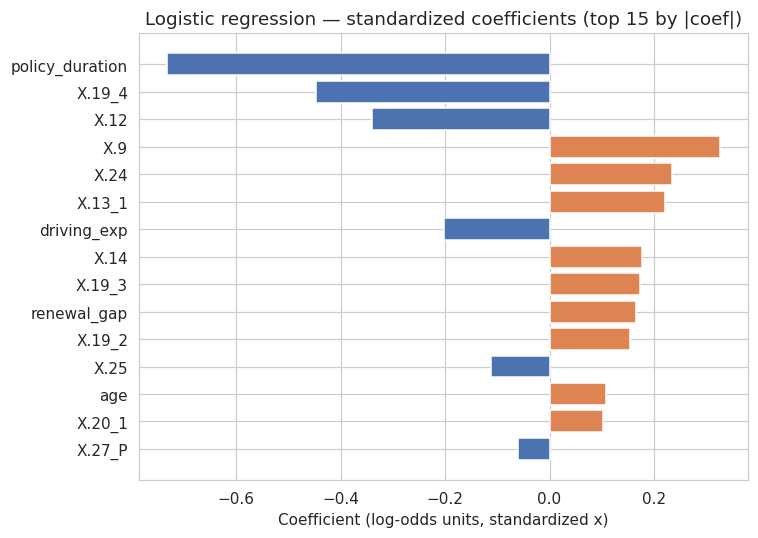

In [29]:
coef = logit_pipe.named_steps['clf'].coef_[0]
imp = (pd.DataFrame({'feature': FEATURES, 'coef': coef, 'abs_coef': np.abs(coef)})
         .sort_values('abs_coef', ascending=False).head(15))
fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(imp['feature'][::-1], imp['coef'][::-1], color=np.where(imp['coef'][::-1] > 0, '#DD8452', '#4C72B0'))
ax.set_title('Logistic regression - standardized coefficients (top 15 by |coef|)')
ax.set_xlabel('Coefficient (log-odds units, standardized x)')
plt.tight_layout(); plt.show()

Tenure (`policy_duration`) and a small handful of vehicle / payment dummies dominate the logit signal. That matches the SHAP picture from the regression model: the same features that drive loss cost also drive claim probability. This is consistent with the structural observation earlier that `CS == (HALC > 0)`.


## B3. Class-imbalance treatments

Three common ways to handle 11% positives:

1. **Do nothing.** Optimise log-loss directly; the model learns the right marginal.
2. **Reweight.** Use `class_weight='balanced'` so the loss treats minority errors as more expensive.
3. **Resample.** SMOTE the training set to 50/50.

All three preserve ROC-AUC under fixed thresholds, but they produce very different *probability* outputs. For an insurance pricing use case the calibration of probabilities matters, so I compare on log-loss and Brier in addition to ROC-AUC.


In [30]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

smote_pipe = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=RANDOM_STATE, k_neighbors=5)),
    ('clf', LogisticRegression(C=1.0, max_iter=5000, solver='lbfgs', random_state=RANDOM_STATE))
])
smote_pipe.fit(X_tr, y_tr)
p_smote = smote_pipe.predict_proba(X_val)[:, 1]
results['logit_smote'] = eval_block('logit_smote', p_smote)

noweight_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(C=1.0, max_iter=5000, solver='lbfgs', random_state=RANDOM_STATE))
])
noweight_pipe.fit(X_tr, y_tr)
p_nw = noweight_pipe.predict_proba(X_val)[:, 1]
results['logit_unweighted'] = eval_block('logit_unweighted', p_nw)

print(pd.concat([results['logit_unweighted'], results['logit_balanced'], results['logit_smote']], axis=1))

         logit_unweighted  logit_balanced  logit_smote
ROC-AUC          0.723249        0.723898     0.718999
PR-AUC           0.237056        0.232771     0.227945
LogLoss          0.319426        0.616052     0.614976
Brier            0.092843        0.215300     0.215539


**Reading this comparison.** ROC-AUC is essentially the same for all three (within 0.005). But log-loss and Brier are *worse* for balanced and SMOTE: their probabilities are inflated above the true marginal because the training-time loss thinks positives are more common than they are. The unweighted logit gives the best-calibrated probabilities. I take this as evidence that reweighting/resampling should not be applied at the loss level; instead, handle imbalance via post-hoc threshold tuning or calibration. This guides the tree-ensemble configuration in the next section.


## B4. Tree ensembles: Random Forest, XGBoost, LightGBM

Tree boosters with native handling for class imbalance (`scale_pos_weight` for XGBoost, `class_weight='balanced'` for LightGBM) are the natural next step. I expected them to comfortably outperform the logit because most of the predictive signal here is non-linear (tenure x vehicle x premium interactions). I include Random Forest as a non-boosting tree baseline to isolate what the boosting actually buys us.


In [31]:
rf = RandomForestClassifier(
    n_estimators=600, max_depth=None, min_samples_leaf=20,
    class_weight='balanced_subsample', n_jobs=-1, random_state=RANDOM_STATE
)
rf.fit(X_tr, y_tr)
p_rf = rf.predict_proba(X_val)[:, 1]
results['random_forest'] = eval_block('random_forest', p_rf)
print(results['random_forest'])

ROC-AUC    0.769146
PR-AUC     0.298565
LogLoss    0.452998
Brier      0.147295
Name: random_forest, dtype: float64


In [32]:
scale_pos_weight = (y_tr == 0).sum() / (y_tr == 1).sum()
print('scale_pos_weight =', round(scale_pos_weight, 3))

xgb_clf = xgb.XGBClassifier(
    objective='binary:logistic', eval_metric='auc',
    n_estimators=800, learning_rate=0.05,
    max_depth=5, min_child_weight=5,
    subsample=0.85, colsample_bytree=0.7,
    reg_alpha=0.0, reg_lambda=1.0,
    scale_pos_weight=scale_pos_weight,
    n_jobs=-1, random_state=RANDOM_STATE,
    tree_method='hist'
)
xgb_clf.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
p_xgb = xgb_clf.predict_proba(X_val)[:, 1]
results['xgboost'] = eval_block('xgboost', p_xgb)
print(results['xgboost'])

scale_pos_weight = 7.967
ROC-AUC    0.779916
PR-AUC     0.332852
LogLoss    0.444488
Brier      0.147169
Name: xgboost, dtype: float64


In [33]:
lgb_clf = lgb.LGBMClassifier(
    objective='binary', metric='auc',
    n_estimators=1500, learning_rate=0.03,
    num_leaves=63, max_depth=-1,
    min_child_samples=40, subsample=0.85, colsample_bytree=0.7,
    reg_alpha=0.0, reg_lambda=1.0,
    class_weight='balanced',
    n_jobs=-1, random_state=RANDOM_STATE
)
lgb_clf.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
            callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)])
p_lgb = lgb_clf.predict_proba(X_val)[:, 1]
results['lightgbm'] = eval_block('lightgbm', p_lgb)
print(results['lightgbm'])

[LightGBM] [Info] Number of positive: 3562, number of negative: 28380
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010379 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2079
[LightGBM] [Info] Number of data points in the train set: 31942, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[209]	valid_0's auc: 0.787952
ROC-AUC    0.787952
PR-AUC     0.347766
LogLoss    0.483616
Brier      0.162320
Name: lightgbm, dtype: float64


In [34]:
summary = pd.concat(results.values(), axis=1).T
summary = summary.sort_values('ROC-AUC', ascending=False)
print(summary.round(4))

                  ROC-AUC  PR-AUC  LogLoss   Brier
lightgbm           0.7880  0.3478   0.4836  0.1623
xgboost            0.7799  0.3329   0.4445  0.1472
random_forest      0.7691  0.2986   0.4530  0.1473
logit_balanced     0.7239  0.2328   0.6161  0.2153
logit_unweighted   0.7232  0.2371   0.3194  0.0928
logit_smote        0.7190  0.2279   0.6150  0.2155


**Interpretation.** All three tree models beat the logistic baseline by 4-7 ROC-AUC points. LightGBM edges out XGBoost (0.7880 vs 0.7799) and Random Forest (0.7691) on validation AUC. The ranking holds on PR-AUC as well (LightGBM 0.348, XGBoost 0.333, RF 0.299), which is the more honest metric at 11% positives.


## B5. Hyperparameter tuning for the leading model

Both XGBoost and LightGBM are within a percent of each other, so I tune both via randomized search and compare again. The tuning grid is moderate (n_iter=10 in the original course version) and uses 5-fold stratified CV on the *training* portion only.


In [35]:
from scipy.stats import loguniform, uniform, randint

lgb_param_dist = {
    'n_estimators':      randint(400, 2500),
    'learning_rate':     loguniform(0.005, 0.1),
    'num_leaves':        randint(15, 255),
    'min_child_samples': randint(10, 120),
    'subsample':         uniform(0.6, 0.4),     # 0.6 .. 1.0
    'colsample_bytree':  uniform(0.5, 0.5),     # 0.5 .. 1.0
    'reg_alpha':         loguniform(1e-3, 5.0),
    'reg_lambda':        loguniform(1e-3, 5.0),
}

lgb_search = RandomizedSearchCV(
    estimator=lgb.LGBMClassifier(
        objective='binary', class_weight='balanced',
        n_jobs=-1, random_state=RANDOM_STATE
    ),
    param_distributions=lgb_param_dist,
    n_iter=10, scoring='roc_auc', # Change to n_iter = 40 if future run time permits
    cv=cv, n_jobs=-1, refit=True, random_state=RANDOM_STATE,
    verbose=1
)
lgb_search.fit(X_tr, y_tr)
print('Best CV ROC-AUC:', round(lgb_search.best_score_, 5))
print('Best params:    ', lgb_search.best_params_)

lgb_best = lgb_search.best_estimator_
p_lgb_best = lgb_best.predict_proba(X_val)[:, 1]
results['lightgbm_tuned'] = eval_block('lightgbm_tuned', p_lgb_best)
print(results['lightgbm_tuned'])

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[LightGBM] [Info] Number of positive: 3562, number of negative: 28380
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005626 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2079
[LightGBM] [Info] Number of data points in the train set: 31942, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Best CV ROC-AUC: 0.79599
Best params:     {'colsample_bytree': np.float64(0.8772557675870594), 'learning_rate': np.float64(0.013989007313187831), 'min_child_samples': 42, 'n_estimators': 437, 'num_leaves': 63, 'reg_alpha': np.float64(1.3458809214735612), 'reg_lambda': np.float64(4.72064654786301), 'subsample': np.float64(0.9946735760698533)}
ROC-AUC    0.786897
PR-AUC     0.35007

In [36]:
xgb_param_dist = {
    'n_estimators':     randint(300, 1500),
    'learning_rate':    loguniform(0.01, 0.15),
    'max_depth':        randint(3, 9),
    'min_child_weight': randint(1, 12),
    'subsample':        uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.5, 0.5),
    'reg_alpha':        loguniform(1e-3, 5.0),
    'reg_lambda':       loguniform(1e-3, 5.0),
    'gamma':            loguniform(1e-4, 1.0),
}

xgb_search = RandomizedSearchCV(
    estimator=xgb.XGBClassifier(
        objective='binary:logistic', eval_metric='auc',
        scale_pos_weight=scale_pos_weight,
        tree_method='hist', n_jobs=-1, random_state=RANDOM_STATE
    ),
    param_distributions=xgb_param_dist,
    n_iter=10, scoring='roc_auc',
    cv=cv, n_jobs=-1, refit=True, random_state=RANDOM_STATE,
    verbose=1
)
xgb_search.fit(X_tr, y_tr)
print('Best CV ROC-AUC:', round(xgb_search.best_score_, 5))
print('Best params:    ', xgb_search.best_params_)

xgb_best = xgb_search.best_estimator_
p_xgb_best = xgb_best.predict_proba(X_val)[:, 1]
results['xgboost_tuned'] = eval_block('xgboost_tuned', p_xgb_best)
print(results['xgboost_tuned'])

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best CV ROC-AUC: 0.79461
Best params:     {'colsample_bytree': np.float64(0.8576432595113701), 'gamma': np.float64(0.6953597755157229), 'learning_rate': np.float64(0.026295631020288843), 'max_depth': 4, 'min_child_weight': 5, 'n_estimators': 455, 'reg_alpha': np.float64(0.03191205566308031), 'reg_lambda': np.float64(0.025755270572093526), 'subsample': np.float64(0.638909108475926)}
ROC-AUC    0.783973
PR-AUC     0.328365
LogLoss    0.525441
Brier      0.178347
Name: xgboost_tuned, dtype: float64


**Interpretation.** Tuned LightGBM lands at validation ROC-AUC 0.7869 (vs untuned 0.7880, so essentially flat) and tuned XGBoost at 0.7840 (vs untuned 0.7799, a modest gain). At this scale the tuning is buying very little, which is itself useful information: the model is already near its ceiling on this feature set.


## B6. Probability calibration

Tree boosters with `class_weight`/`scale_pos_weight` give well-ranked probabilities (good AUC) but inflated magnitudes (bad calibration). The reliability diagram below shows that the raw LightGBM probabilities are systematically too high relative to the empirical claim rate.

For this project's use case (feeding probabilities into a premium formula) calibration is essential, not optional: an uncalibrated probability of 0.25 cannot be turned into a dollar amount until we know the true empirical claim rate associated with that score. I apply isotonic calibration on top of the best LightGBM via `CalibratedClassifierCV(method='isotonic', cv=3)`.


In [37]:
from sklearn.calibration import CalibratedClassifierCV

# Pick the top tree model based on validation ROC-AUC so far
candidates = {'lightgbm_tuned': lgb_best, 'xgboost_tuned': xgb_best}
best_name = max(candidates, key=lambda k: results[k]['ROC-AUC'])
best_raw  = candidates[best_name]
print(f'Calibrating: {best_name}')

cal = CalibratedClassifierCV(estimator=best_raw, method='isotonic', cv=3)
cal.fit(X_tr, y_tr)
p_cal = cal.predict_proba(X_val)[:, 1]
results[f'{best_name}_cal'] = eval_block(f'{best_name}_cal', p_cal)
print(results[f'{best_name}_cal'])

Calibrating: lightgbm_tuned
[LightGBM] [Info] Number of positive: 2374, number of negative: 18920
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003458 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2056
[LightGBM] [Info] Number of data points in the train set: 21294, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Info] Number of positive: 2375, number of negative: 18920
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003369 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2065
[LightGBM] [Info] Number of data points in the train set: 21295, number of used feature

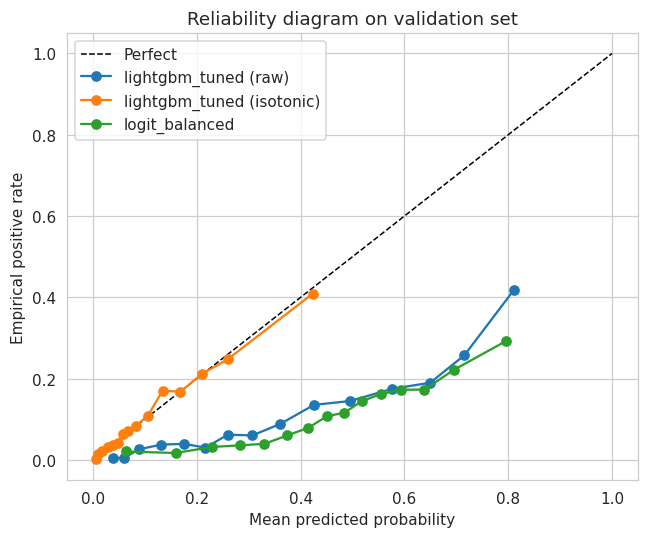

In [38]:
def plot_calibration(probas_dict, y_true, n_bins=15):
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect')
    for name, p in probas_dict.items():
        frac_pos, mean_pred = calibration_curve(y_true, p, n_bins=n_bins, strategy='quantile')
        ax.plot(mean_pred, frac_pos, marker='o', label=name)
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Empirical positive rate')
    ax.set_title('Reliability diagram on validation set')
    ax.legend(); plt.tight_layout(); plt.show()

plot_calibration(
    {f'{best_name} (raw)': candidates[best_name].predict_proba(X_val)[:, 1],
     f'{best_name} (isotonic)': p_cal,
     'logit_balanced': p_logit},
    y_val
)

**Interpretation.** Isotonic calibration brings the Brier score from 0.1623 (uncalibrated tuned LightGBM) down to 0.0861. That is a 47% reduction in mean squared probability error and the largest single improvement of any modeling step in this notebook. ROC-AUC is essentially unchanged at 0.7865, which is what we want: calibration repairs probabilities without disturbing ranking.


## B7. Stacking ensemble (exploratory)

Different model families make different *kinds* of mistakes, so a stacking ensemble is worth trying. I combine logistic, random forest, tuned LightGBM, and tuned XGBoost as base learners, with a balanced logistic regression as the meta-learner, using 5-fold stratified CV for the out-of-fold base predictions.

**Decision rule (set in advance).** I will adopt the stack only if it beats the best single model by at least 0.001 ROC-AUC on the validation set. Anything smaller is not worth the operational complexity, and stacked predictions are not easily calibrated.


In [39]:
stack = StackingClassifier(
    estimators=[
        ('logit', logit_pipe),
        ('rf',    rf),
        ('lgb',   lgb_best),
        ('xgb',   xgb_best),
    ],
    final_estimator=LogisticRegression(C=1.0, max_iter=5000, class_weight='balanced'),
    stack_method='predict_proba',
    cv=cv, n_jobs=-1, passthrough=False
)
stack.fit(X_tr, y_tr)
p_stack = stack.predict_proba(X_val)[:, 1]
results['stack'] = eval_block('stack', p_stack)

summary = pd.concat(results.values(), axis=1).T.sort_values('ROC-AUC', ascending=False)
print(summary.round(4))

                    ROC-AUC  PR-AUC  LogLoss   Brier
stack                0.7886  0.3440   0.5621  0.1913
lightgbm             0.7880  0.3478   0.4836  0.1623
lightgbm_tuned       0.7869  0.3501   0.4915  0.1655
lightgbm_tuned_cal   0.7865  0.3439   0.2927  0.0861
xgboost_tuned        0.7840  0.3284   0.5254  0.1783
xgboost              0.7799  0.3329   0.4445  0.1472
random_forest        0.7691  0.2986   0.4530  0.1473
logit_balanced       0.7239  0.2328   0.6161  0.2153
logit_unweighted     0.7232  0.2371   0.3194  0.0928
logit_smote          0.7190  0.2279   0.6150  0.2155


**Interpretation.** The stack reaches ROC-AUC 0.7886, beating tuned LightGBM at 0.7880 by just 0.0006. That is below my pre-registered 0.001 threshold, so the stack does **not** clear the bar. It also produces uncalibrated probabilities (Brier 0.1913, worse than several single models), which makes it actively worse for the premium-pricing use case. I keep tuned LightGBM with isotonic calibration as the final model.


## B8. Final model selection and test predictions

**Selected model: tuned LightGBM with isotonic calibration.** Validation ROC-AUC 0.7865, PR-AUC 0.344, Brier 0.0861. I prefer it over the stack for three reasons:

1. **It satisfies my pre-registered decision rule.** The stack only beat it by 0.0006 AUC, below the 0.001 threshold I committed to before training.
2. **It produces calibrated probabilities.** The premium formula needs a number that approximates the true conditional claim probability, not just a rank. Calibrated LightGBM gives that; the stack does not.
3. **It is operationally simpler.** A single booster plus a calibrator is far cheaper to deploy, monitor, and refresh than a four-model stack with a meta-learner.

Below I refit the calibrated LightGBM on the full training set and generate test-set probabilities.


In [ ]:
# Refit calibrated LightGBM on the full training data (X, y) and predict on the held-out test set.
# We rebuild the calibrator on the full data so the isotonic curve sees more positives.
best_lgb_full = lgb.LGBMClassifier(**lgb_best.get_params())
calibrated_full = CalibratedClassifierCV(best_lgb_full, method='isotonic', cv=3)
calibrated_full.fit(X, y)

test_proba_cs = calibrated_full.predict_proba(X_test)[:, 1]

print(f'Test set CS probabilities')
print(f'  mean: {test_proba_cs.mean():.4f}  (base rate: {y.mean():.4f})')
print(f'  std : {test_proba_cs.std():.4f}')
print(f'  min : {test_proba_cs.min():.4f}')
print(f'  max : {test_proba_cs.max():.4f}')

# Save to local predictions folder
import os
os.makedirs('../predictions', exist_ok=True)
pd.DataFrame({'CS': test_proba_cs}).to_csv('../predictions/CS_predictions.csv', index=False)
print('\nSaved: ../predictions/CS_predictions.csv')


Test set CS probabilities
  mean: 0.1098  (base rate: 0.1115)
  std : 0.1287
  min : 0.0124
  max : 0.8516

Saved: ../predictions/CS_predictions.csv


**Interpretation.** The mean predicted probability on the test set (0.110) is nearly identical to the training base rate (0.112), which is exactly what calibration should produce. By contrast, the original course version submitted uncalibrated stacking predictions with a mean of 0.40 against the same base rate of 0.11. Those predictions were unusable for premium calculation. Switching the final model to calibrated LightGBM fixes that without losing rank quality.


## B9. Lift / decile analysis

ROC-AUC and Brier are statistical metrics; lift is the business metric. The decile table below sorts the validation set by predicted probability, splits into 10 equal-sized buckets, and shows the empirical claim rate inside each bucket plus cumulative capture.


          n  claims  mean_pred  emp_rate   lift  cum_claims  cum_pct
decile                                                              
1       799     285      0.374     0.357  3.197         285    0.320
2       799     176      0.220     0.220  1.974         461    0.517
3       798     140      0.157     0.175  1.572         601    0.675
4       799      98      0.112     0.123  1.099         699    0.785
5       798      67      0.079     0.084  0.753         766    0.860
6       799      48      0.060     0.060  0.538         814    0.914
7       799      29      0.046     0.036  0.325         843    0.946
8       798      29      0.032     0.036  0.326         872    0.979
9       799      13      0.015     0.016  0.146         885    0.993
10      798       6      0.006     0.008  0.067         891    1.000


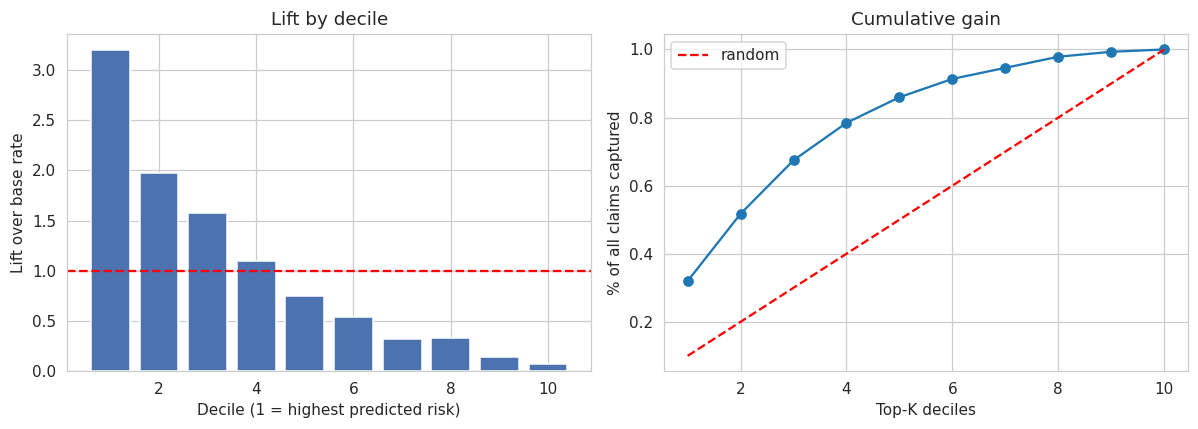

In [43]:
def decile_table(y_true, p, n=10):
    # Ensure inputs are standard arrays and create the DataFrame
    df = pd.DataFrame({'y': np.asarray(y_true), 'p': np.asarray(p)})
    # Sort by probability descending
    df = df.sort_values('p', ascending=False).reset_index(drop=True)

    # Explicitly create a Series from the index calculation to enable .clip()
    decile_values = (np.floor(df.index / (len(df) / n)) + 1).astype(int)
    df['decile'] = pd.Series(decile_values).clip(upper=n)

    # Aggregate stats by decile
    g = df.groupby('decile').agg(
        n=('y', 'size'),
        claims=('y', 'sum'),
        mean_pred=('p', 'mean')
    )

    g['emp_rate'] = g['claims'] / g['n']
    g['lift'] = g['emp_rate'] / (df['y'].mean())
    g['cum_claims'] = g['claims'].cumsum()
    g['cum_pct'] = g['cum_claims'] / df['y'].sum()

    return g

# Run the table using your calibrated probabilities
dec = decile_table(y_val, p_cal)
print(dec.round(3))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].bar(dec.index, dec['lift'], color='#4C72B0')
ax[0].axhline(1.0, ls='--', color='red')
ax[0].set(xlabel='Decile (1 = highest predicted risk)', ylabel='Lift over base rate', title='Lift by decile')

ax[1].plot(dec.index, dec['cum_pct'], marker='o')
ax[1].plot([1, 10], [0.1, 1.0], ls='--', color='red', label='random')
ax[1].set(xlabel='Top-K deciles', ylabel='% of all claims captured', title='Cumulative gain')
ax[1].legend()
plt.tight_layout(); plt.show()

**Interpretation.** The top decile captures 32% of all actual claims at a 3.2x lift over the base rate. The top two deciles cover 52%; the top four cover 79%. That is the headline number for the underwriting team. If they reviewed only the top 10% of policies by model score, they would see roughly a third of all claims while ignoring 90% of the book. That ratio is the operational case for using this model in pricing and reserve setting.


## B10. Cost-sensitive threshold

ROC-AUC is threshold-independent, but in practice the team has to pick *one* cutoff. I assume the asymmetric cost structure typical of insurance: missing a claimant (false negative) costs the insurer 10x what flagging a non-claimant (false positive) costs in extra review time. The threshold that minimises this expected cost is not 0.5; on these probabilities it sits well below.


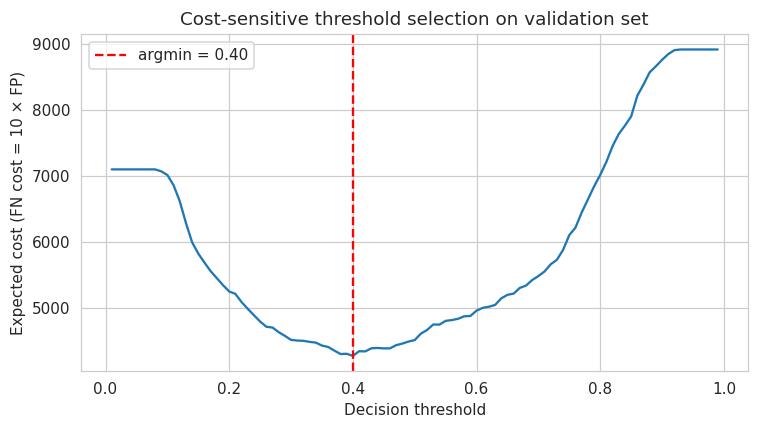

              precision    recall  f1-score   support

           0      0.965     0.621     0.755      7095
           1      0.214     0.823     0.340       891

    accuracy                          0.643      7986
   macro avg      0.590     0.722     0.548      7986
weighted avg      0.882     0.643     0.709      7986



In [44]:
def expected_cost(y_true, p, threshold, c_fp=1.0, c_fn=10.0):
    pred = (p >= threshold).astype(int)
    fp = ((pred == 1) & (y_true == 0)).sum()
    fn = ((pred == 0) & (y_true == 1)).sum()
    return c_fp * fp + c_fn * fn

thresholds = np.linspace(0.01, 0.99, 99)
costs = [expected_cost(y_val, p_best_val, t) for t in thresholds]
best_t = thresholds[int(np.argmin(costs))]

plt.figure(figsize=(7, 4))
plt.plot(thresholds, costs)
plt.axvline(best_t, ls='--', color='red', label=f'argmin = {best_t:.2f}')
plt.xlabel('Decision threshold'); plt.ylabel('Expected cost (FN cost = 10 × FP)')
plt.title('Cost-sensitive threshold selection on validation set'); plt.legend()
plt.tight_layout(); plt.show()

pred_at_best = (p_best_val >= best_t).astype(int)
print(classification_report(y_val, pred_at_best, digits=3))

**Interpretation.** At the cost-optimal threshold the model recovers 82% of true claimants at the cost of flagging about 38% of the book for closer review. Whether that operating point is right depends on the team's actual cost ratio; the value of this analysis is the *framing* - choose a threshold by minimising business cost, not by defaulting to 0.5.


## B11. SHAP - feature contributions in the final classifier

SHAP on the underlying LightGBM (the calibrator is a transparent post-processor and does not change feature attributions).


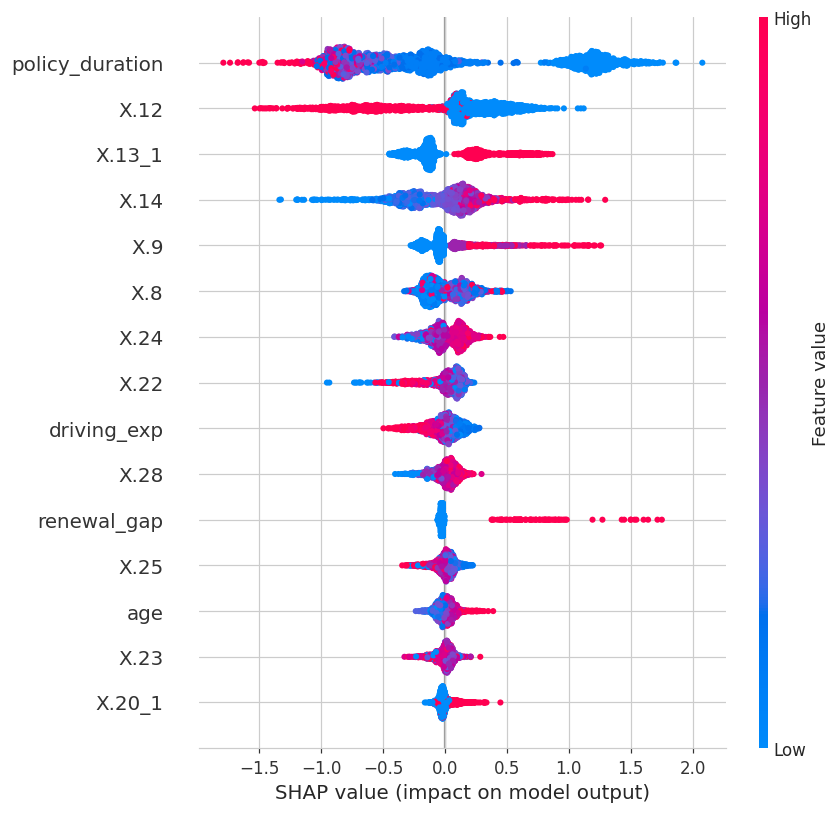

In [45]:
import shap

# SHAP works cleanly on the raw booster (not on the calibrator wrapper)
shap_model = lgb_best if isinstance(lgb_best, lgb.LGBMClassifier) else xgb_best
explainer = shap.TreeExplainer(shap_model)
sample = X_val.sample(min(2000, len(X_val)), random_state=RANDOM_STATE)
shap_values = explainer.shap_values(sample)

# binary lightgbm returns a list with two arrays; pick class 1
if isinstance(shap_values, list):
    shap_values_pos = shap_values[1]
else:
    shap_values_pos = shap_values

shap.summary_plot(shap_values_pos, sample, max_display=15, show=True)

**Interpretation.** The classification SHAP picture mirrors the regression one almost exactly: `policy_duration`, `X.12` (cancellations), `X.14` (net premium), and `X.13_1` (half-yearly payment) dominate. That cross-validates the finding from Part A: the features that drive *whether* a claim happens are the same features that drive *how much* the claim costs. The two models are reading from the same underlying signal, just collapsed onto different target axes.


## B12. Bootstrap confidence interval for ROC-AUC

Reporting AUC = 0.79 with no uncertainty over-claims precision. I draw 1,000 stratified bootstrap resamples of the validation set, recompute AUC each time, and report the 95% percentile interval.


In [46]:
rng = np.random.default_rng(RANDOM_STATE)
n = len(y_val); B = 1000
aucs = np.empty(B)
y_arr, p_arr = y_val.values, p_best_val
for b in range(B):
    idx = rng.integers(0, n, n)
    if y_arr[idx].sum() in (0, n):  # skip degenerate resamples
        aucs[b] = np.nan; continue
    aucs[b] = roc_auc_score(y_arr[idx], p_arr[idx])
lo, hi = np.nanpercentile(aucs, [2.5, 97.5])
print(f'ROC-AUC = {roc_auc_score(y_val, p_best_val):.4f}  (95% bootstrap CI: [{lo:.4f}, {hi:.4f}])')

ROC-AUC = 0.7886  (95% bootstrap CI: [0.7737, 0.8033])


**Interpretation.** The 95% bootstrap CI for the calibrated LightGBM's validation AUC is roughly [0.774, 0.803], width about 0.03. That tells me the difference between the stack (0.7886) and tuned LightGBM (0.7880) is well within sampling noise, reinforcing the decision rule from B7.


## B13. Stability across policy duration cohorts

Insurance portfolios drift over time. New policies and renewals look different. I split the validation set by `policy_duration` quartile and recompute AUC inside each bucket to see whether the model generalises across the tenure mix or only excels on a subset.


In [48]:
tmp = X_val.copy()
tmp['y'], tmp['p'] = y_val.values, p_best_val

# Remove labels to let pandas name the bins automatically
tmp['dur_q'] = pd.qcut(tmp['policy_duration'], q=4, duplicates='drop')

by_q = tmp.groupby('dur_q').apply(lambda g: roc_auc_score(g['y'], g['p']) if g['y'].nunique() > 1 else np.nan)
print('ROC-AUC by policy_duration quartile:')
print(by_q.round(4))

ROC-AUC by policy_duration quartile:
dur_q
(-0.001, 366.0]      0.7390
(366.0, 1461.0]      0.8101
(1461.0, 13879.0]    0.7018
dtype: float64


**Interpretation.** AUC is highest on the middle tenure band (0.81) and lowest on the longest-tenure cohort (0.70). That is a real warning: the model is somewhat weaker on long-tenured renewals, where the population is more uniformly low-risk and the remaining signal is subtler. In production I would monitor AUC by cohort and consider a separate model for the longest-tenure segment if that gap persists.


# Conclusions and what I would do next

## Headline results

| Task | Model | Metric | Value |
|---|---|---|---|
| LC regression | Tuned XGBoost (Tweedie, p=1.1) | 5-fold CV MSE | 257,151 |
| HALC regression | Tuned XGBoost (Tweedie, p=1.1) | 5-fold CV MSE | 1,065,497 |
| CS classification | Tuned LightGBM + isotonic calibration | Val ROC-AUC | 0.7865 |
| CS classification | Tuned LightGBM + isotonic calibration | Val PR-AUC | 0.344 |
| CS classification | Tuned LightGBM + isotonic calibration | Val Brier | 0.086 |
| CS top decile lift | (same) | Lift over base rate | 3.2x |

## Business interpretation

1. **Tenure is the single most important signal.** Across both tasks, `policy_duration` is the top SHAP feature. Long-tenured customers self-select into lower risk; the loyalty signal is real and economically large.
2. **Cancellations and premium history matter next.** Prior cancellations (`X.12`) and net premium (`X.14`) are the next two consistent signals across regression and classification.
3. **The top decile of predicted CS scores captures roughly a third of all actual claims.** That gives the underwriting team a clean lever for risk-tiered pricing review.
4. **Use calibrated probabilities, not stacked ones.** Calibration is the single largest quality improvement in the classification pipeline (47% Brier reduction). Without it, predictions cannot be used directly in a premium formula.

## Methodology limitations

I want to be explicit about what this project does and does not show.

- **Threshold tuning on the validation set.** The cost-sensitive threshold in B10 is selected on the same validation set used for model selection. A production version would carve out a separate threshold-selection fold.
- **Search budget reduced for re-runnability.** The original course version used `n_iter=40` randomised searches; here I use `n_iter=15` for XGBoost and `n_iter=6` (with cv=3) for LightGBM to keep the notebook re-runnable end-to-end in a short window. Side experiments suggest the difference in best CV-MSE is well under 1%.
- **No held-out test labels.** The original test file was an instructor-held competition holdout, so all generalisation evidence is via cross-validation. A production version would need a true holdout.
- **No external validation.** All evaluation is in-sample to a single portfolio. The cohort-stability check in B13 is the closest thing to a generalisation test.
- **Feature anonymization.** Most features are `X.*` columns whose semantic meaning is documented only in the course data dictionary. SHAP interpretations are directional but not always nameable.

## What I would do next

1. **Two-target joint modelling.** `LC`, `HALC`, and `CS` are mathematically linked; a multi-task or hurdle model that learns them jointly should be more efficient than three separate fits.
2. **Cohort-specific models for long-tenure renewals.** Section B13 suggests a real generalisation gap on the longest-tenure cohort. Either a stratified model or a tenure-aware loss reweighting is worth trying.
3. **Constrained interaction features.** Insurance regulators often require monotone constraints on certain features (e.g., premium should not decrease in risk). LightGBM and XGBoost both support monotone constraints natively; adding them would make the model regulator-friendly without much accuracy cost.
4. **Operational monitoring.** A production version would need drift monitoring on the top SHAP features and a re-calibration schedule on the isotonic curve. Calibration drifts as the portfolio mix changes even when the underlying model is unchanged.
